In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

print(pl.__version__)
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)

1.43.0


In [3]:
sales=pd.read_csv(r"C:\Users\Nikesh\Enterprise-Demand-Forecasting\data\raw\sales_train_evaluation.csv")
sales.head()
calendar = pd.read_csv(r"C:\Users\Nikesh\Enterprise-Demand-Forecasting\data\raw\calendar.csv")

In [4]:
# Aggregate daily sales directly from the wide-format dataset
daily_sales = sales.iloc[:, 6:].sum(axis=0).reset_index()
daily_sales.columns = ["d", "sales"]

# Merge with calendar to get actual dates and event information
daily_sales = daily_sales.merge(calendar, on="d", how="left")

# Convert date column to datetime
daily_sales["date"] = pd.to_datetime(daily_sales["date"])

daily_sales.head()
daily_sales.shape
daily_sales.nunique()

d               1941
sales           1885
date            1941
wm_yr_wk         278
weekday            7
wday               7
month             12
year               6
event_name_1      30
event_type_1       4
event_name_2       4
event_type_2       2
snap_CA            2
snap_TX            2
snap_WI            2
dtype: int64

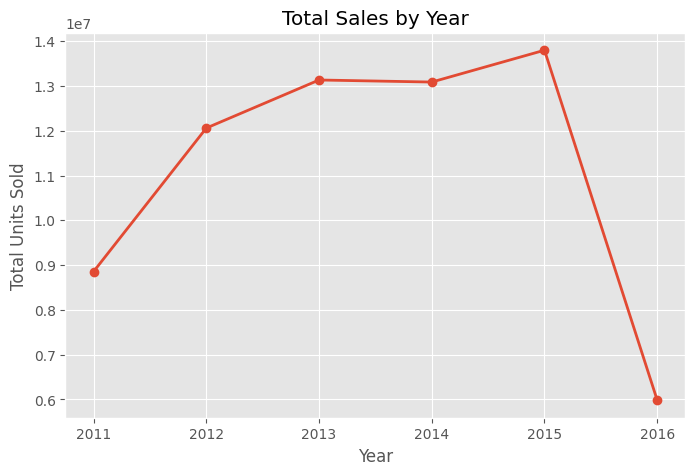

In [5]:
yearly_sales = daily_sales.groupby("year")["sales"].sum().reset_index() #Aggregation of sales for an year 

plt.figure(figsize=(8,5))
plt.plot(yearly_sales["year"], yearly_sales["sales"], marker="o", linewidth=2)

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Units Sold")

plt.show()
#The decline in 2016 does not indicate reduced business performance. 
#The dataset contains sales only until June 2016, making the yearly total incomplete. 
#Similarly, 2011 is a partial year since data begins on January 29, 2011.

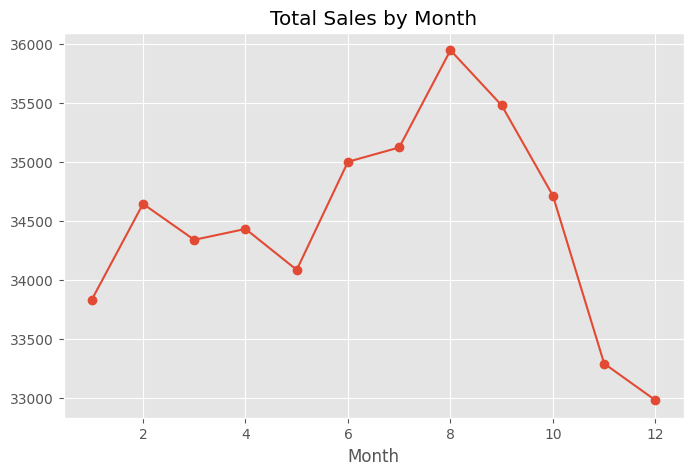

In [6]:
monthly_Sales = daily_sales.groupby("month")["sales"].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(monthly_Sales["month"],monthly_Sales["sales"],marker="o")
plt.title("Total Sales by Month")
plt.xlabel("Month")

plt.show()

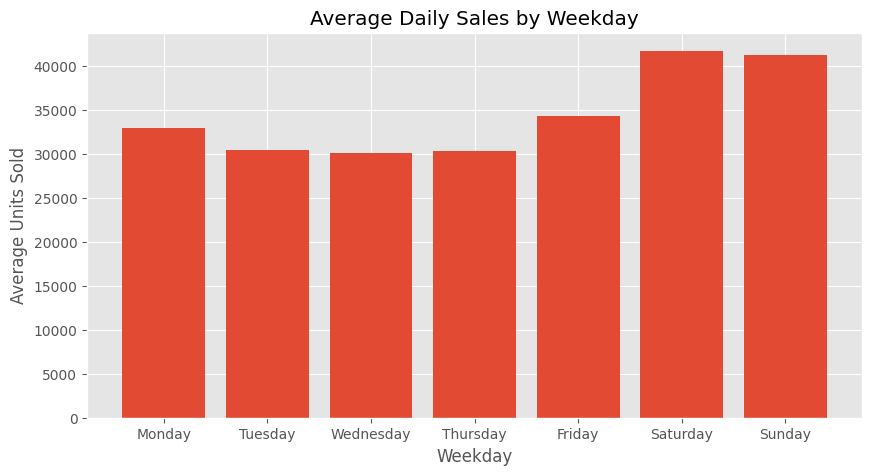

In [42]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_sales = (
    daily_sales.groupby("weekday")["sales"]
    .mean()
    .reindex(weekday_order)
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.bar(weekday_sales["weekday"], weekday_sales["sales"])

plt.title("Average Daily Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Units Sold")

plt.show()

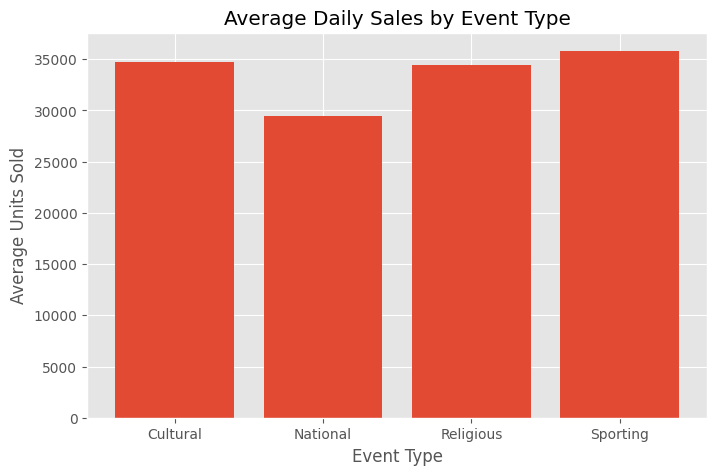

In [7]:
event_sales = (
    daily_sales.groupby("event_type_1")["sales"]
    .mean()
    .reset_index()
)

event_sales["event_type_1"] = event_sales["event_type_1"].fillna("No Event")

plt.figure(figsize=(8,5))
plt.bar(event_sales["event_type_1"], event_sales["sales"])

plt.title("Average Daily Sales by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average Units Sold")

plt.show()



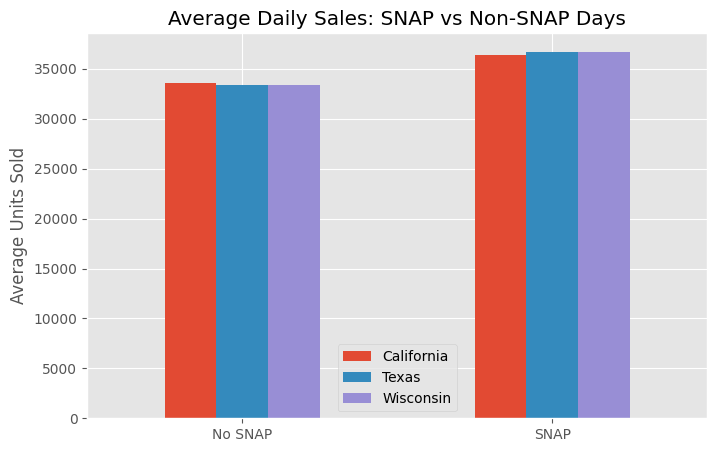

In [8]:
#SNAP(Supplemental Nutrition Assistance Program) 
snap_sales = {
    "California": daily_sales.groupby("snap_CA")["sales"].mean(),
    "Texas": daily_sales.groupby("snap_TX")["sales"].mean(),
    "Wisconsin": daily_sales.groupby("snap_WI")["sales"].mean()
}

snap_df = pd.DataFrame(snap_sales)
snap_df.index = ["No SNAP", "SNAP"]

snap_df.plot(kind="bar", figsize=(8,5))

plt.title("Average Daily Sales: SNAP vs Non-SNAP Days")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)

plt.show()

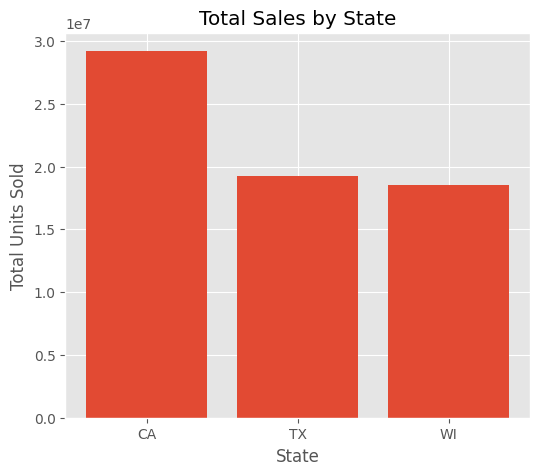

In [9]:
# Total sales by state
state_sales = (
    sales.groupby("state_id")
    .sum(numeric_only=True)
    .iloc[:, :]
    .sum(axis=1)
    .reset_index()
)

state_sales.columns = ["State", "Total_Sales"]

plt.figure(figsize=(6,5))
plt.bar(state_sales["State"], state_sales["Total_Sales"])

plt.title("Total Sales by State")
plt.xlabel("State")
plt.ylabel("Total Units Sold")

plt.show()

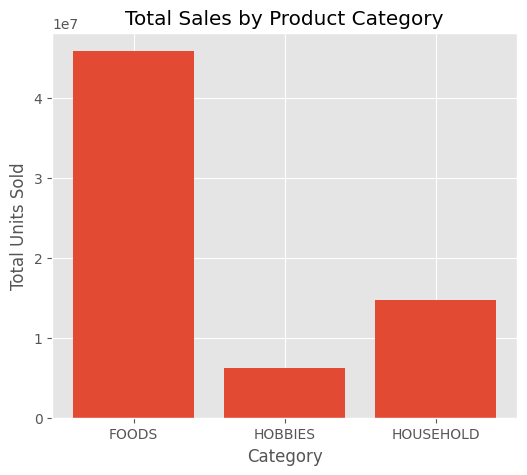

In [10]:
# Total sales by product category

category_sales = (
    sales.groupby("cat_id")
    .sum(numeric_only=True)
    .sum(axis=1)
    .reset_index()
)

category_sales.columns = ["Category", "Total_Sales"]

plt.figure(figsize=(6,5))
plt.bar(category_sales["Category"], category_sales["Total_Sales"])

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")

plt.show()

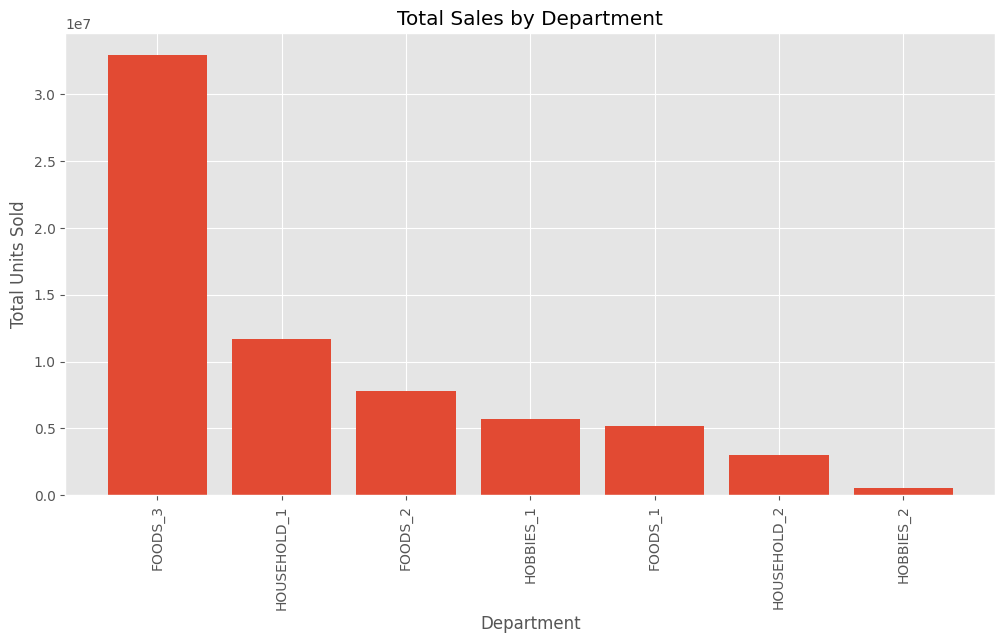

In [11]:
# Total sales by department

department_sales = (
    sales.groupby("dept_id")
    .sum(numeric_only=True)
    .sum(axis=1)
    .sort_values(ascending=False)
    .reset_index()
)

department_sales.columns = ["Department", "Total_Sales"]

plt.figure(figsize=(12,6))
plt.bar(department_sales["Department"], department_sales["Total_Sales"])

plt.title("Total Sales by Department")
plt.xlabel("Department")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=90)

plt.show()

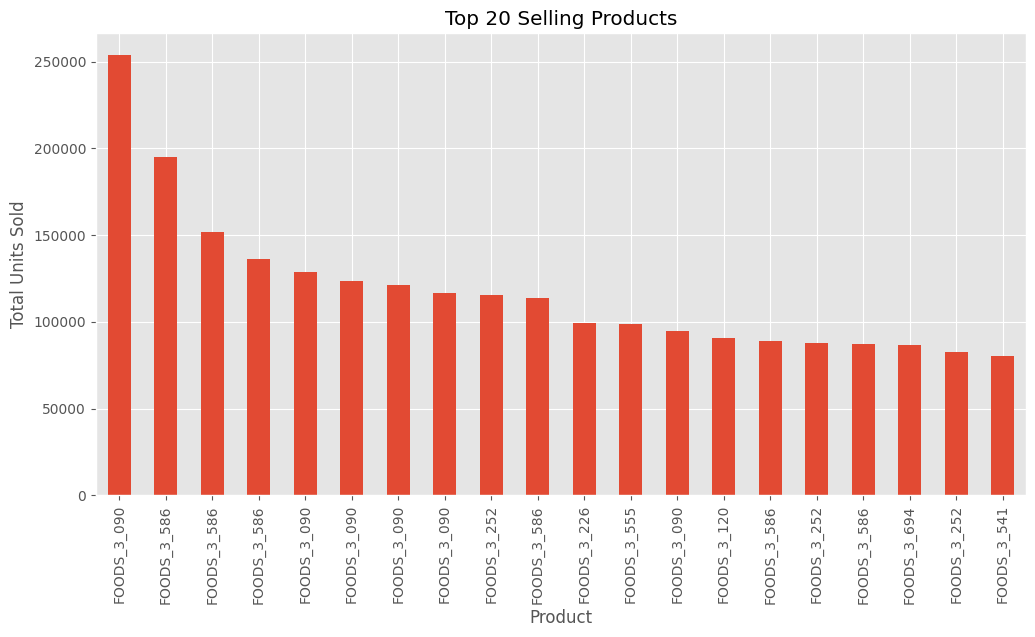

In [52]:
# Top 20 selling products

top_products = (
    sales.set_index("item_id")
    .iloc[:, 6:]
    .sum(axis=1)
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))
top_products.plot(kind="bar")

plt.title("Top 20 Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Units Sold")

plt.show()

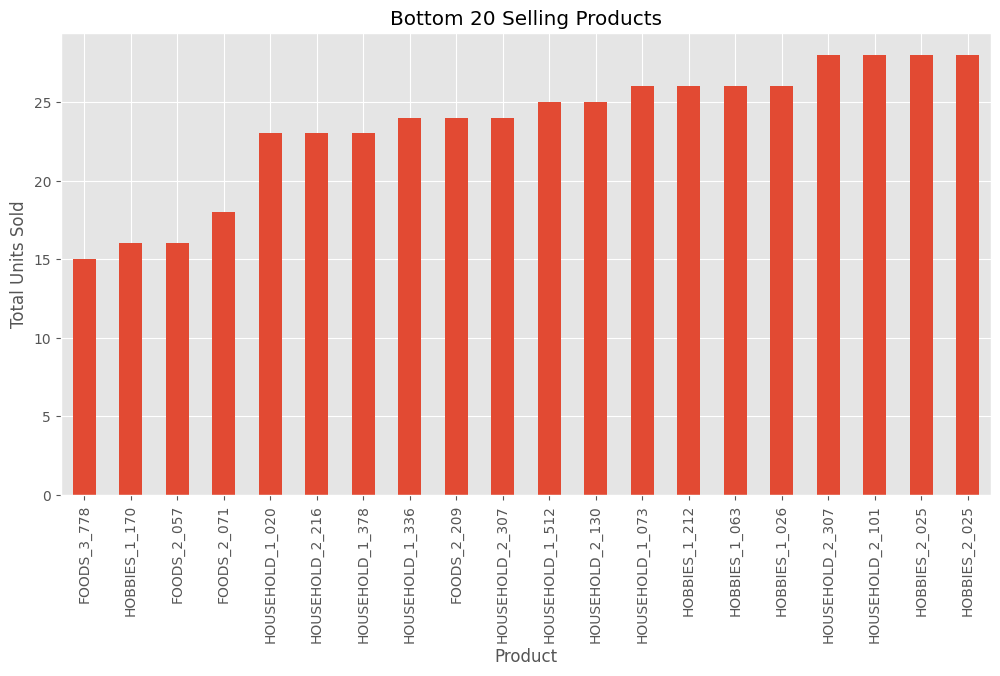

In [53]:
# Bottom 20 selling products

bottom_products = (
    sales.set_index("item_id")
    .iloc[:, 6:]
    .sum(axis=1)
    .sort_values(ascending=True)
    .head(20)
)

plt.figure(figsize=(12,6))
bottom_products.plot(kind="bar")

plt.title("Bottom 20 Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Units Sold")

plt.show()

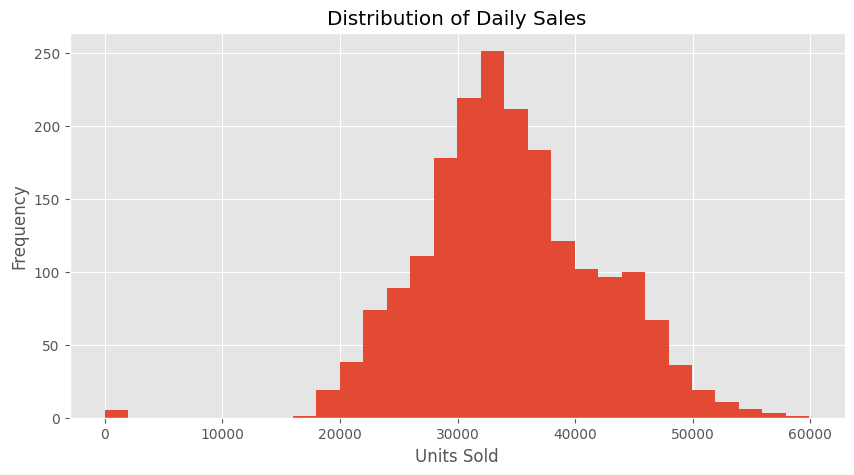

In [54]:
plt.figure(figsize=(10,5))
plt.hist(daily_sales["sales"], bins=30)

plt.title("Distribution of Daily Sales")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.show()
# Most daily sales fall between 30,000 and 40,000 units. slightly right skewed

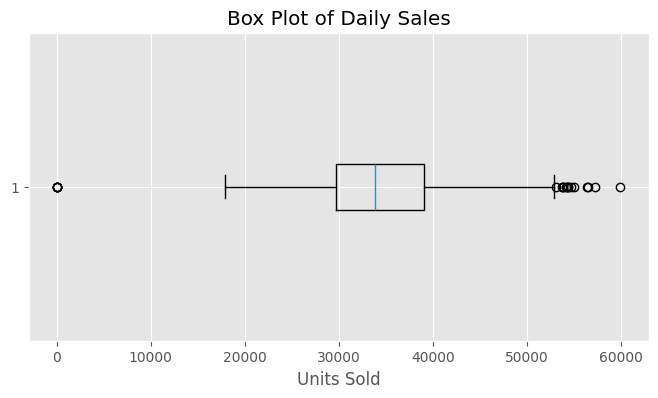

In [55]:
# outlier check with boxplot
plt.figure(figsize=(8,4))
plt.boxplot(daily_sales["sales"], vert=False)

plt.title("Box Plot of Daily Sales")
plt.xlabel("Units Sold")

plt.show()
# Daily sales are generally stable, with occasional extreme highs and one extreme low. 
# These outliers should be investigated rather than removed.
# They may represent important business events that influence demand forecasting.

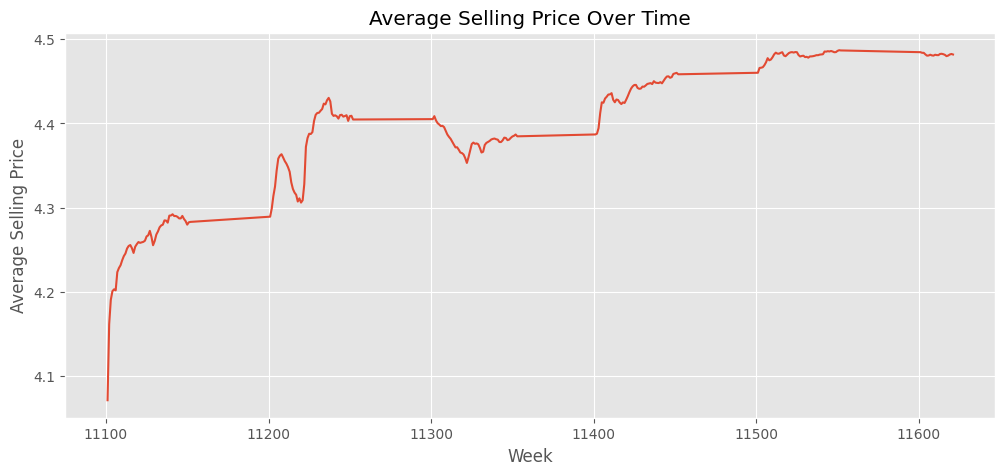

In [56]:
# Load price dataset
prices = pd.read_csv(r"C:\Users\Nikesh\Downloads\archive (2)\sell_prices.csv")

# Average selling price by week
weekly_price = (
    prices.groupby("wm_yr_wk")["sell_price"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))
plt.plot(weekly_price["wm_yr_wk"], weekly_price["sell_price"])

plt.title("Average Selling Price Over Time")
plt.xlabel("Week")
plt.ylabel("Average Selling Price")

plt.show()

In [12]:
import polars as pl

sales = pl.read_csv(
    r"C:\Users\Nikesh\Downloads\archive (2)\sales_train_evaluation.csv"
)

calendar = pl.read_csv(
    r"C:\Users\Nikesh\Downloads\archive (2)\calendar.csv"
)

prices = pl.read_csv(
    r"C:\Users\Nikesh\Downloads\archive (2)\sell_prices.csv"
)

In [13]:
print(sales.shape)
print(calendar.shape)
print(prices.shape)

(30490, 1947)
(1969, 14)
(6841121, 4)


In [15]:
id_columns = [
    "id",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

In [17]:
long_sales = sales.unpivot(
    index=id_columns,
    variable_name="d",
    value_name="sales"
)

In [18]:
long_sales = long_sales.join(
    calendar,
    on="d",
    how="left"
)

In [20]:
long_sales = long_sales.join(
    prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

In [21]:
id_columns = [
    "id",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

long_sales = sales.unpivot(
    index=id_columns,
    variable_name="d",
    value_name="sales"
)

In [22]:
print(long_sales.shape)
long_sales.head()

(59181090, 8)


id,item_id,dept_id,cat_id,store_id,state_id,d,sales
str,str,str,str,str,str,str,i64
"""HOBBIES_1_001_CA_1_evaluation""","""HOBBIES_1_001""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0
"""HOBBIES_1_002_CA_1_evaluation""","""HOBBIES_1_002""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0
"""HOBBIES_1_003_CA_1_evaluation""","""HOBBIES_1_003""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0
"""HOBBIES_1_004_CA_1_evaluation""","""HOBBIES_1_004""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0
"""HOBBIES_1_005_CA_1_evaluation""","""HOBBIES_1_005""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0


In [24]:
long_sales = long_sales.join(
    calendar,
    on="d",
    how="left"
)

print(long_sales.shape)
long_sales.head()

(59181090, 34)


id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,date_right,wm_yr_wk_right,weekday_right,wday_right,month_right,year_right,event_name_1_right,event_type_1_right,event_name_2_right,event_type_2_right,snap_CA_right,snap_TX_right,snap_WI_right
str,str,str,str,str,str,str,i64,str,i64,str,i64,i64,i64,str,str,str,str,i64,i64,i64,str,i64,str,i64,i64,i64,str,str,str,str,i64,i64,i64
"""HOBBIES_1_001_CA_1_evaluation""","""HOBBIES_1_001""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0
"""HOBBIES_1_002_CA_1_evaluation""","""HOBBIES_1_002""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0
"""HOBBIES_1_003_CA_1_evaluation""","""HOBBIES_1_003""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0
"""HOBBIES_1_004_CA_1_evaluation""","""HOBBIES_1_004""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0
"""HOBBIES_1_005_CA_1_evaluation""","""HOBBIES_1_005""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0


In [25]:
long_sales = long_sales.join(
    prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

print(long_sales.shape)
long_sales.head()

(59181090, 35)


id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,date_right,wm_yr_wk_right,weekday_right,wday_right,month_right,year_right,event_name_1_right,event_type_1_right,event_name_2_right,event_type_2_right,snap_CA_right,snap_TX_right,snap_WI_right,sell_price
str,str,str,str,str,str,str,i64,str,i64,str,i64,i64,i64,str,str,str,str,i64,i64,i64,str,i64,str,i64,i64,i64,str,str,str,str,i64,i64,i64,f64
"""HOBBIES_1_001_CA_1_evaluation""","""HOBBIES_1_001""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,null
"""HOBBIES_1_002_CA_1_evaluation""","""HOBBIES_1_002""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,null
"""HOBBIES_1_003_CA_1_evaluation""","""HOBBIES_1_003""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,null
"""HOBBIES_1_004_CA_1_evaluation""","""HOBBIES_1_004""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,null
"""HOBBIES_1_005_CA_1_evaluation""","""HOBBIES_1_005""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,null


In [27]:
# Save the master dataset

import os

# Create processed folder if it doesn't exist
processed_path = r"C:\Users\Nikesh\Enterprise-Demand-Forecasting\data\processed"
os.makedirs(processed_path, exist_ok=True)

# Save as Parquet
long_sales.write_parquet(
    os.path.join(processed_path, "master_dataset.parquet")
)

print("✅ Master dataset saved successfully!")
print(f"Location: {os.path.join(processed_path, 'master_dataset.parquet')}")

✅ Master dataset saved successfully!
Location: C:\Users\Nikesh\Enterprise-Demand-Forecasting\data\processed\master_dataset.parquet
